# Explorando os dados

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import matplotlib.pyplot as plt
import keras_tuner as kt
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
url ='https://github.com/allanspadini/curso-tensorflow-proxima-palavra/raw/main/dados/train.zip'

df = pd.read_csv(url, header=None, names=['ClassIndex', 'Título', 'Descrição'])

In [ ]:
df

,ClassIndex,Título,Descrição
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
...,...,...,...
119995,1,Pakistan's Musharraf Says Won't Quit as Army C...,KARACHI (Reuters) - Pakistani President Perve...
119996,2,Renteria signing a top-shelf deal,Red Sox general manager Theo Epstein acknowled...
119997,2,Saban not going to Dolphins yet,The Miami Dolphins will put their courtship of...
119998,2,Today's NFL games,PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...


In [ ]:
df['text'] = df['Título'] + ' ' + df['Descrição']

df.text

,text
0,Wall St. Bears Claw Back Into the Black (Reute...
1,Carlyle Looks Toward Commercial Aerospace (Reu...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,Iraq Halts Oil Exports from Main Southern Pipe...
4,"Oil prices soar to all-time record, posing new..."
...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...
119996,Renteria signing a top-shelf deal Red Sox gene...
119997,Saban not going to Dolphins yet The Miami Dolp...
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...


In [ ]:
df['ClassIndex'].value_counts()

,count
ClassIndex,
3,30000
4,30000
2,30000
1,30000


In [ ]:
df['ClassIndex'] = df['ClassIndex'] - 1
df['ClassIndex'].value_counts()

,count
ClassIndex,
2,30000
3,30000
1,30000
0,30000


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df['text'].values, df['ClassIndex'].values,
                                                    test_size=0.2, random_state=425)

VOCAB_SIZE = 10000
encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder.adapt(X_train)

In [ ]:
encoder.get_vocabulary()[::10]

['',
 '39s',
 'it',
 'was',
 'two',
 'company',
 '39',
 'microsoft',
 'prices',
 'government',
 'off',
 'some',
 'announced',
 'news',
 'court',
 'chief',
 'league',
 'third',
 'network',
 'according',
 'san',
 'plan',
 '1',
 'growth',
 'quarter',
 'being',
 'move',
 'him',
 'nations',
 'many',
 'executive',
 'users',
 'drug',
 'six',
 'economic',
 'iran',
 'much',
 'title',
 'attacks',
 'st',
 'contract',
 'french',
 'face',
 'chicago',
 'seven',
 'future',
 'hurricane',
 'strike',
 'half',
 'gets',
 'office',
 'militants',
 'chip',
 'hostage',
 'whether',
 'scored',
 'field',
 'match',
 'winning',
 'chinese',
 'rate',
 'east',
 'oct',
 'injured',
 'profits',
 'reach',
 'almost',
 'ipod',
 'nov',
 'coast',
 'sale',
 '16',
 '7',
 'council',
 'local',
 'concerns',
 'competition',
 'until',
 'supply',
 'visit',
 'george',
 'finally',
 'yards',
 'airways',
 'ruling',
 'failed',
 'each',
 'ivan',
 'palestinians',
 'continued',
 'dollars',
 'jones',
 'children',
 'name',
 'mission',
 'bring

## Definição do primeiro modelo

In [ ]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=16,
        mask_zero=False
    ),
    tf.keras.layers.Conv1D(64, kernel_size=3, activation='relu'),
    tf.keras.layers.MaxPooling1D(),
    tf.keras.layers.Conv1D(128, kernel_size=3, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

Valor de teste do modelo:

In [ ]:
X_test[:1], y_test[1]

(array(['Threats trail man organizing Gaza withdrawal The criticism from members of his own kibbutz marked the first sign of trouble for Yonatan Bassi. Then came the comparisons to Nazis and death threats.'],
       dtype=object),
 3)

In [ ]:
model.predict(X_test[:1]).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


array([0])

In [ ]:
epochs = 10
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    validation_data=(X_test, y_test))

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.5053 - loss: 1.0895 - val_accuracy: 0.8789 - val_loss: 0.3854
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 36s 8ms/step - accuracy: 0.8799 - loss: 0.3789 - val_accuracy: 0.8918 - val_loss: 0.3455
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.9003 - loss: 0.3222 - val_accuracy: 0.9001 - val_loss: 0.3197
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - accuracy: 0.9097 - loss: 0.2921 - val_accuracy: 0.9027 - val_loss: 0.3094
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9192 - loss: 0.2642 - val_accuracy: 0.9028 - val_loss: 0.3047
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9213 - loss: 0.2498 - val_accuracy: 0.9042 - val_loss: 0.2992
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9236 - loss: 0.2444 - val_accuracy: 0.9039 - val_loss: 0.3004
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 45s 8ms/step - accuracy: 0.9270 - loss: 0

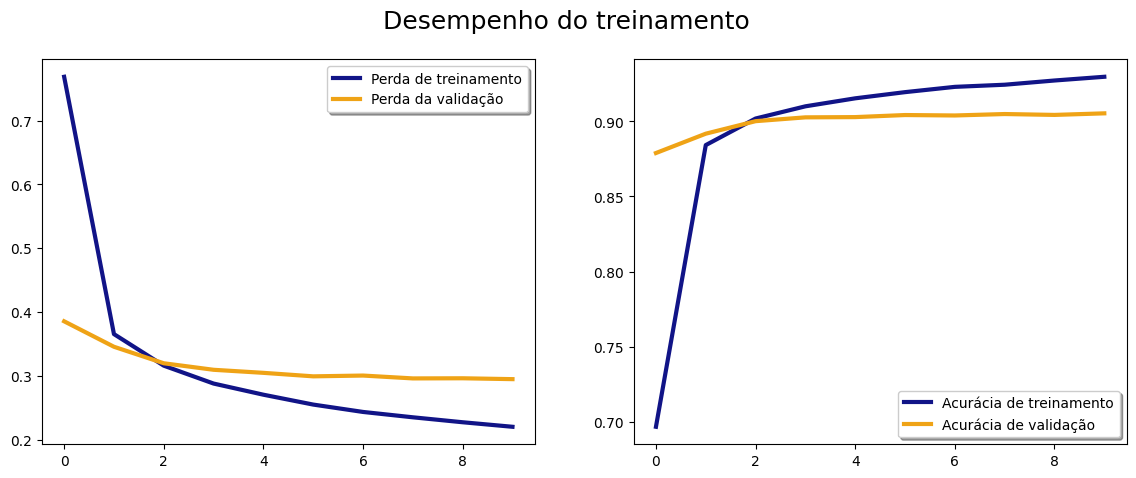

In [ ]:
def plotar_graficos(history):
    fig, ax = plt.subplots(1,2, figsize=(14,5))
    ax[0].plot(history.history['loss'], color='#111487', linewidth=3, label="Perda de treinamento")
    ax[0].plot(history.history['val_loss'], color='#EFA316', linewidth=3, label="Perda da validação")
    ax[0].legend(loc='best', shadow=True)

    ax[1].plot(history.history['accuracy'], color='#111487', linewidth=3, label="Acurácia de treinamento")
    ax[1].plot(history.history['val_accuracy'], color='#EFA316', linewidth=3, label="Acurácia de validação")
    ax[1].legend(loc='best', shadow=True)

    plt.suptitle('Desempenho do treinamento', fontsize = 18)
    plt.show()

plotar_graficos(history)

## Utilizando camada LSTM

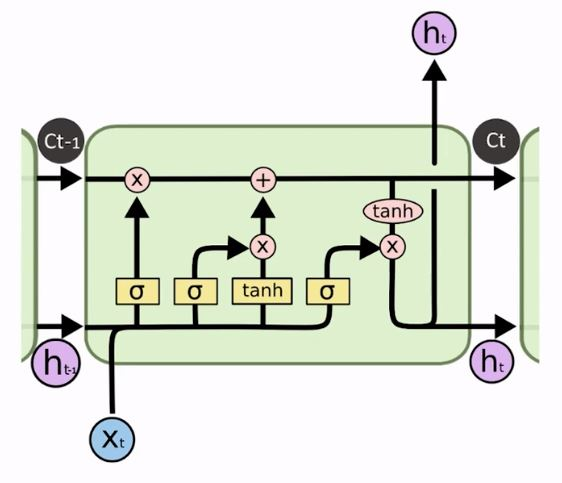

In [ ]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
epochs = 20
history = model.fit(X_train, y_train,
                    epochs=epochs,
                    validation_data=(X_test, y_test))

Epoch 1/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - accuracy: 0.6395 - loss: 0.8388 - val_accuracy: 0.8951 - val_loss: 0.3181
Epoch 2/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 82s 19ms/step - accuracy: 0.9081 - loss: 0.3079 - val_accuracy: 0.9093 - val_loss: 0.2762
Epoch 3/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 86s 20ms/step - accuracy: 0.9264 - loss: 0.2468 - val_accuracy: 0.9113 - val_loss: 0.2646
Epoch 4/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 78s 19ms/step - accuracy: 0.9388 - loss: 0.2098 - val_accuracy: 0.9110 - val_loss: 0.2727
Epoch 5/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 86s 20ms/step - accuracy: 0.9439 - loss: 0.1883 - val_accuracy: 0.9099 - val_loss: 0.2853
Epoch 6/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 84s 21ms/step - accuracy: 0.9500 - loss: 0.1687 - val_accuracy: 0.9066 - val_loss: 0.2939
Epoch 7/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 21ms/step - accuracy: 0.9544 - loss: 0.1521 - val_accuracy: 0.9071 - val_loss: 0.3037
Epoch 8/20
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 76s 19ms/step - accuracy: 0.9593 -

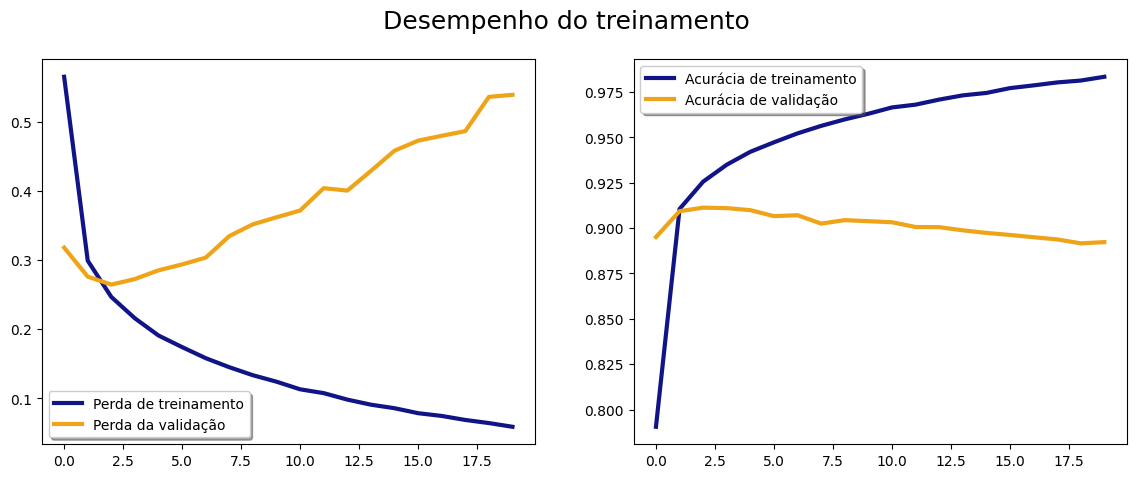

In [ ]:
plotar_graficos(history)

## Utilizando Keras Tuner para busca de melhores hiperparâmetros

In [ ]:
def build_model(hp):
    model = tf.keras.Sequential([
        encoder,
        tf.keras.layers.Embedding(
            input_dim=len(encoder.get_vocabulary()),
            output_dim=hp.Int('embedding_dim', min_value=32, max_value=128, step=32),
            mask_zero=True
        ),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
            units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
            return_sequences=True
        )),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(
            units=hp.Int('lstm_units', min_value=16, max_value=64, step=16)
        )),
        tf.keras.layers.Dense(
            units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
            activation='relu'
        ),
        tf.keras.layers.Dropout(rate=hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)),
        tf.keras.layers.Dense(4, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=5,
    factor=3,
    directory='my_dir',
    project_name='classification_optimization'
)

def run_tuner(X,y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_index, test_index in kf.split(X):
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]

        tuner.search(X_train_fold, y_train_fold, epochs=10,
                     validation_data=(X_test_fold, y_test_fold))

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"""
          O número ideal de dimensões de incorporação(Embedding) é {best_hps.get('embedding_dim')},
          o número ideal de unidades LSTM é {best_hps.get('lstm_units')}, e
          o número ideal de unidades densas é {best_hps.get('dense_units')},
          e a taxa de abandono ideal(Dropout) é {best_hps.get('dropout')}.
    """)
    return best_hps

best_hps = run_tuner(X_train, y_train)

Trial 10 Complete [00h 06m 17s]
val_accuracy: 0.9111979007720947

Best val_accuracy So Far: 0.9111979007720947
Total elapsed time: 00h 35m 40s

          O número ideal de dimensões de incorporação(Embedding) é 128,
          o número ideal de unidades LSTM é 64, e
          o número ideal de unidades densas é 96,
          e a taxa de abandono ideal(Dropout) é 0.2.
    


In [ ]:
final_model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=best_hps.get('embedding_dim'),
        mask_zero=True
    ),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(best_hps.get('lstm_units'), return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(best_hps.get('lstm_units') // 2)),
    tf.keras.layers.Dense(best_hps.get('dense_units'), activation='relu'),
    tf.keras.layers.Dropout(rate=best_hps.get('dropout')),
    tf.keras.layers.Dense(4, activation='softmax')
])

final_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
final_model.fit(X_train, y_train,
                epochs=10,
                validation_data=(X_test, y_test))

Epoch 1/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - accuracy: 0.7140 - loss: 0.7027 - val_accuracy: 0.9076 - val_loss: 0.2775
Epoch 2/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 73s 19ms/step - accuracy: 0.9212 - loss: 0.2488 - val_accuracy: 0.9134 - val_loss: 0.2581
Epoch 3/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 57s 19ms/step - accuracy: 0.9350 - loss: 0.1986 - val_accuracy: 0.9136 - val_loss: 0.2547
Epoch 4/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - accuracy: 0.9459 - loss: 0.1665 - val_accuracy: 0.9132 - val_loss: 0.2583
Epoch 5/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 81s 19ms/step - accuracy: 0.9492 - loss: 0.1531 - val_accuracy: 0.9101 - val_loss: 0.2726
Epoch 6/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 88s 21ms/step - accuracy: 0.9557 - loss: 0.1348 - val_accuracy: 0.9103 - val_loss: 0.2857
Epoch 7/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 75s 19ms/step - accuracy: 0.9634 - loss: 0.1141 - val_accuracy: 0.9087 - val_loss: 0.3014
Epoch 8/10
3000/3000 ━━━━━━━━━━━━━━━━━━━━ 83s 19ms/step - accuracy: 0.9674 -

In [ ]:
y_pred = final_model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)

750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step


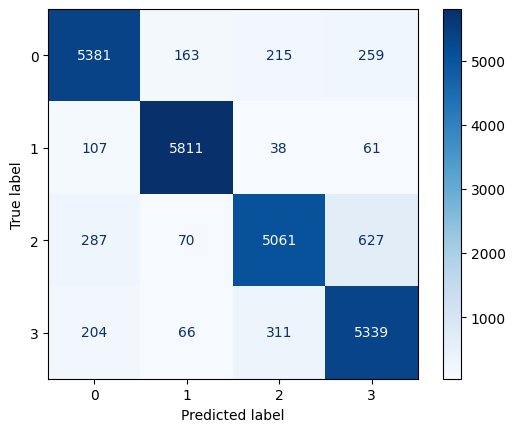

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=[0, 1, 2, 3])

disp.plot(cmap=plt.cm.Blues)
plt.show()

# Pontos Importantes

* Executar a leitura e manipulação de datasets com Pandas.
* Separar dados em conjuntos de treino e teste com sklearn.
* Realizar a tokenização de textos usando TensorFlow e TextVectorization.
* Criar um encoder para transformar textos em números.
* Construir um modelo de rede neural com Keras.
* Implementar camadas Embedding e Pooling.
* Realizar a compilação e treino do modelo com otimizador Adam e função de custo sparseCategoricalCrossEntropy.
* Ativar e utilizar GPU no Lightning AI Studio para aumentar a eficiência do treinamento de modelos de Deep Learning.
* Rodar novamente o código após a ativação da GPU e definir o número de épocas com a variável epochs.
* Implementar e experimentar com camadas convolucionais e de max pooling para melhorar a performance em tarefas de classificação de texto.
* Utilizar camadas LSTM, incluindo LSTM bidirecionais e ajuste na dimensão da camada de embedding, para melhorar o processamento de dados de texto.
* Aplicar camadas de Dropout para combater overfitting após camadas convolucionais, pooling e LSTM.
* Monitorar e verificar a acurácia do modelo durante o treinamento e plotar resultados gráficos utilizando Matplotlib.
* Analisar as probabilidades das predições e utilizar a função argmax para identificar a classe com a maior probabilidade.
* Compreender a ideia de otimização empírica da estrutura da rede neural e a possibilidade de automação para seleção da melhor estrutura de modelo em estudos futuros.
* Como utilizar a biblioteca Keras Tuner para buscar hiperparâmetros ideais em redes neurais.
* Encapsular a definição do modelo em uma função que aceita hiperparâmetros como argumentos.
* Implementar camadas de LSTM e Dense utilizando hiperparâmetros.
* Importância da validação cruzada para tornar os testes mais robustos.
* Utilizar a função KFold da biblioteca sklearn para cross-validation.
* Integrar a busca de hiperparâmetros com dados de validação cruzada.
* Reconstruir um modelo de rede neural utilizando os melhores hiperparâmetros encontrados.
* Importância do uso de GPUs para melhorar a eficiência do processo.